# 방한외국인 한국여행 리뷰 데이터 분석 및 모델링

본 노트북은 여행 앱의 사용자 리뷰 데이터를 분석하여 주요 불만을 식별하고, 토픽 모델링을 통해 숨겨진 주제를 발견하며, 재방문 의향(만족도)을 예측하는 모델을 구축하는 과정을 담고 있습니다.

**분석 흐름 (Analysis Flow):**
1.  **환경 설정 및 데이터 로드 (Setup & Data Loading):** 라이브러리 임포트 및 데이터 불러오기
2.  **데이터 전처리 및 정제 (Preprocessing & Cleaning):** 텍스트 병합, 길이 분석, 중복/스팸 제거, 텍스트 정규화
3.  **탐색적 데이터 분석 (EDA):** 토큰 분포 확인, 불용어 처리
4.  **토픽 모델링 (LDA Topic Modeling):** 리뷰의 주요 주제(테마) 발굴
5.  **예측 모델링 (User Satisfaction Modeling):** '길찾기 불만' 여부를 기반으로 만족도(재방문 의향) 예측 모델 구축
6.  **모델 해석 (Interpretation with SHAP):** 모델 예측에 영향을 미치는 주요 단어 분석

## 1. 환경 설정 및 데이터 로드 (Setup & Data Loading)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import missingno as msno

# 텍스트 분석 및 모델링을 위한 라이브러리
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import shap
import pyLDAvis.lda_model
import matplotlib.pyplot as plt
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
from sklearn.decomposition import LatentDirichletAllocation

# 시각화 설정 (한글 폰트)
plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 데이터 로드
df = pd.read_csv("merged_all_data.csv")
print("데이터 크기:", df.shape)
df.head()

데이터 크기: (39278, 2)


,title,content
0,NaN,"oh... another useless ""expert community"" link ..."
1,NaN,"I DON'T WANT THIS ON MY LOCK SCREEN, LET ME TU..."
2,NaN,"it is so bad, it scales too much, that I do no..."
3,NaN,Completely lost when used on iPhone. I have ve...
4,NaN,The map has been having a lot of issues recent...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39278 entries, 0 to 39277
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    3622 non-null   object
 1   content  37649 non-null  object
dtypes: object(2)
memory usage: 613.8+ KB


In [4]:
df.describe()

,title,content
count,3622,37649
unique,2572,19304
top,&nbsp;,very bad
freq,58,228


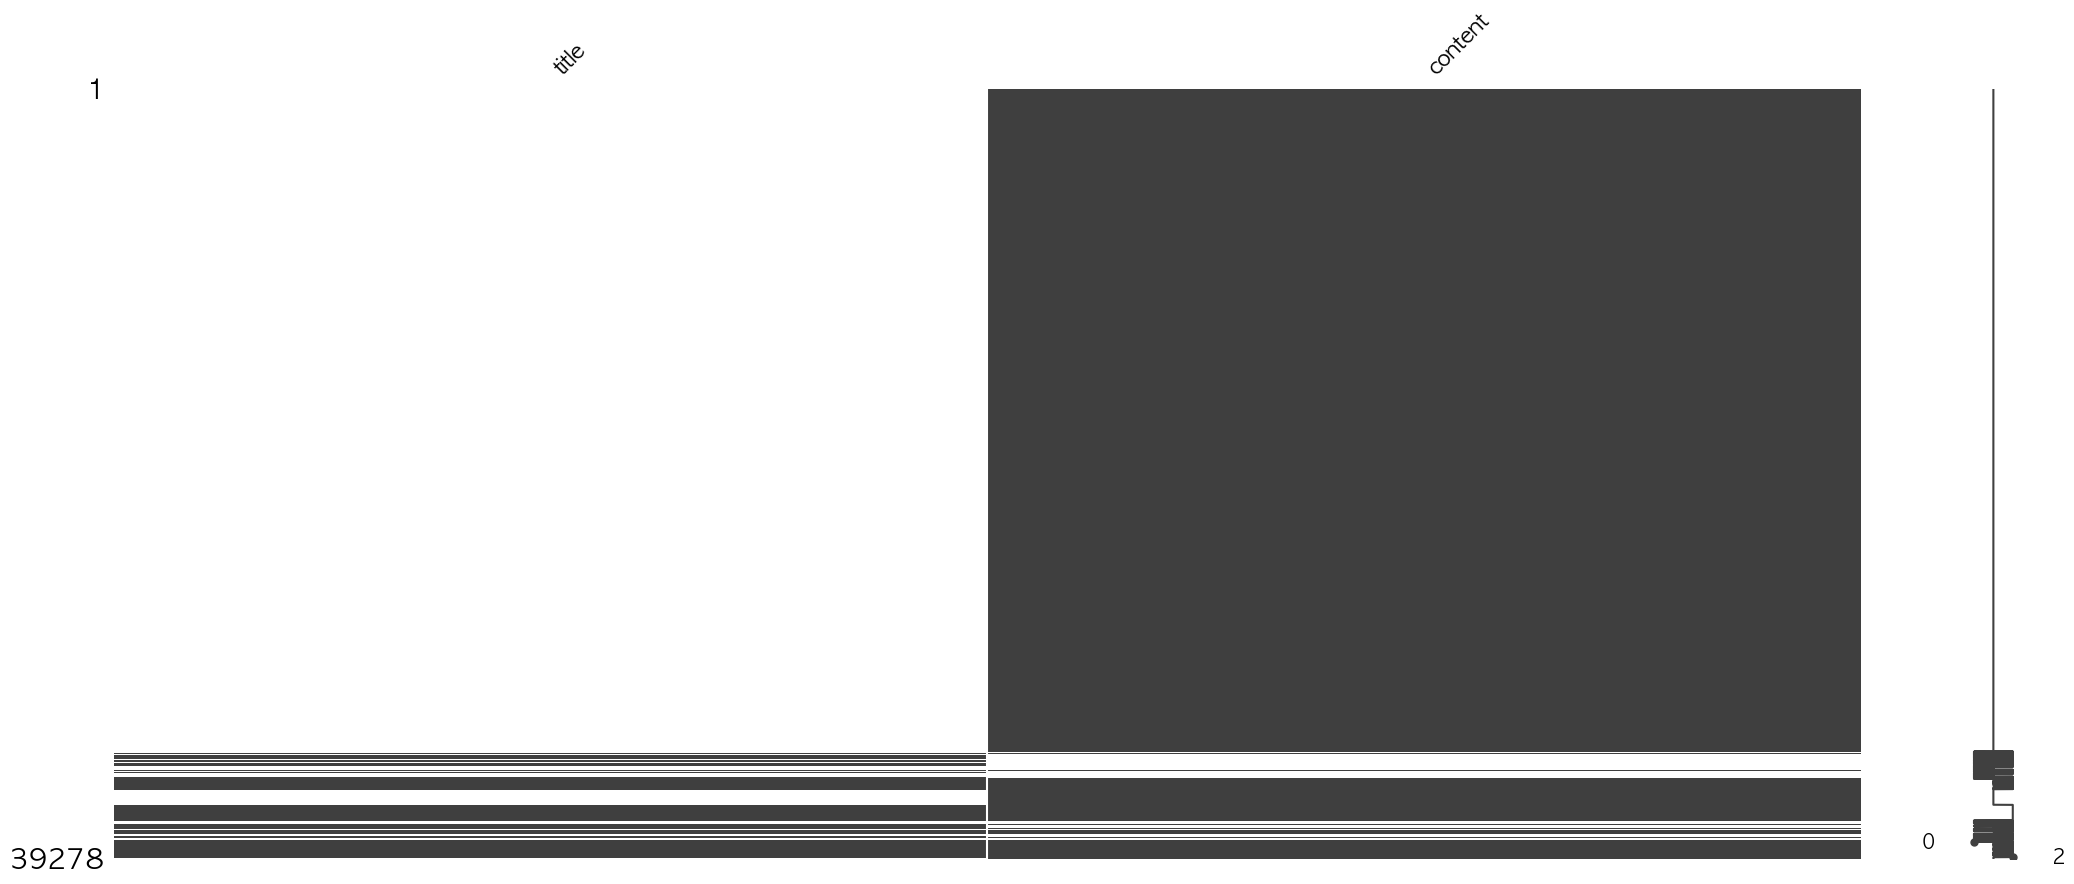

In [5]:
# 결측치 시각화
msno.matrix(df)
plt.show()

- 데이터 결측치 확인 및 분포 이상치 점검
- 결측 패턴 시각화

In [6]:
# 결측치 제거
df.dropna(inplace = True)
df.shape

(2949, 2)

- 의미가 없는 결측치는 제거

### 데이터 개요 분석 (Data Overview Analysis)
- **결측치 패턴**: `msno.matrix` 시각화 결과, 흰색 줄이 많은 컬럼은 데이터가 누락된 곳, 결측치는 NLP 분석에 사용할 수 없으므로 제거

## 2. 데이터 전처리 및 정제 (Preprocessing & Cleaning)
제목과 내용을 합치고, 너무 짧거나 의미 없는 텍스트를 제거하며, 기본적인 텍스트 정제를 수행

In [7]:
# 제목과 내용 병합
df['text'] = df['title'].fillna('') + " " + df['content'].fillna('')
df['text'] = df['text'].astype(str).str.strip()

# 토큰 길이 계산
df["n_tokens"] = df["text"].astype(str).str.split().str.len()
print(df["n_tokens"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

count    2949.000000
mean      466.813835
std       871.378605
min         2.000000
1%          4.000000
5%         12.000000
25%        53.000000
50%       139.000000
75%       416.000000
95%      2174.600000
99%      4820.520000
max      6089.000000
Name: n_tokens, dtype: float64


- 리뷰의 정보가 제목과 본문에 분산되어 있어 하나의 컬럼으로 합쳐 모델이 문맥을 충분히 학습할 수 있도록 구성.

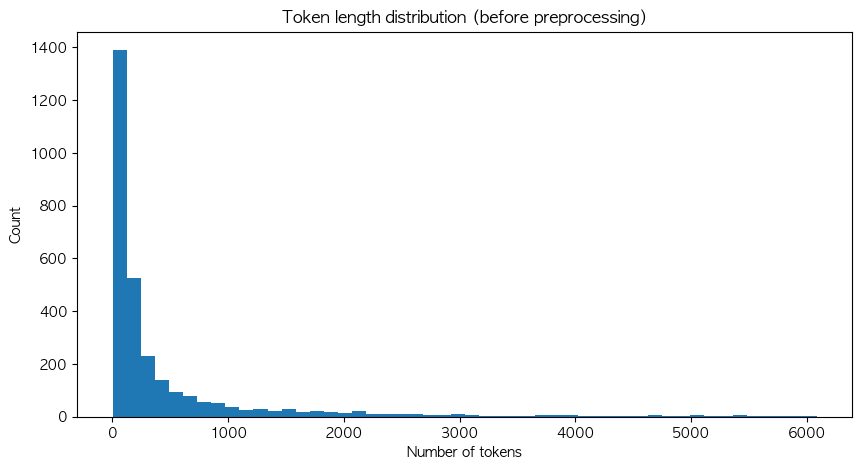

In [8]:
# 토큰 길이 분포 히스토그램
plt.figure(figsize=(10,5))
plt.hist(df["n_tokens"], bins=50)
plt.title("Token length distribution (before preprocessing)")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.show()

In [9]:
# 극단치 예시 확인 (너무 짧거나 긴 리뷰)
short = df.nsmallest(10, "n_tokens")[["text", "n_tokens"]]
long  = df.nlargest(10, "n_tokens")[["text", "n_tokens"]]
print("=== shortest examples ===")
print(short)
print("\n=== longest examples ===")
print(long)

=== shortest examples ===
                  text  n_tokens
35504  Song-do incheon         2
37356            65 60         2
37433             45 1         2
37480    0.1487 0.3785         2
38036    1724058067 46         2
38065  positive 0.2007         2
38256            17 12         2
38309    0.0014 0.4489         2
38419   1747424526 550         2
38424  positive 0.3392         2

=== longest examples ===
                                                    text  n_tokens
38006  Trip Report: Vietnam/Thailand - One Month Been...      6089
34352  [Thank You] On my way to scout for rhubarb, bu...      6034
34362  Got The Thrills for TWICE? Me too! I Went to E...      6022
34241  Nijisanji Info Dump Hi, I've been waffling bac...      5880
34060  Cloudtemplar's Review of Semifinals, KT-GEN (P...      5839
34421  My Full Plastic Surgery Journey in Korea (Rhin...      5820
34190  We Accidentally Allied with a Warrior Race Pt....      5662
37335  [Mega Thread #3] - Review of Korean Langua

- 토큰 길이 시각화를 통해 짧은 글은 의미가 없거나, 너무 긴 것은 스팸, 봇일 가능성을 확인

### 2.1 중복 및 스팸성 리뷰 제거
완전히 동일한 리뷰나, 같은 단어가 반복되는 스팸성 리뷰를 식별하고 제거

In [10]:
# 동일 문장 중복 확인
dup_cnt = df["text"].astype(str).duplicated().sum()

dups = df[df["text"].astype(str).duplicated(keep=False)].copy()
# 스팸성 의심 제거
tokens = df["text"].astype(str).str.split()
df["unique_ratio"] = tokens.apply(lambda x: (len(set(x)) / max(len(x), 1)))
spam_like = df[(df["n_tokens"] >= 30) & (df["unique_ratio"] < 0.3)]
df = df[~((df["n_tokens"] >= 30) & (df["unique_ratio"] < 0.25))].reset_index(drop=True)

In [11]:
df.shape

(2948, 5)

In [12]:
# 너무 짧은 글 제거
df["text"] = df["text"].fillna("").astype(str).str.strip()
df = df[df["text"].str.len() >= 10].copy()

# 중복 제거
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

# 봇/자동응답 패턴 제거
bot_pat = r"moderators subreddit|performed automatically|bot action|please contact|questions concerns|community resources|score|author"
link_pat = r"http|https|www\.|redd\.it|imgur|jpg|png|preview"

df["text"] = df["text"].fillna("").astype(str)

df = df[~df["text"].str.contains(bot_pat, case=False, regex=True, na=False)]
df = df[~df["text"].str.contains(link_pat, case=False, regex=True, na=False)]

- 너무 짧은 텍스트는 모델의 과적합을 방지하기 위해 제거.
- 봇 패턴은 실제 사용자 불만과 무관하지만, 특정 단어에 대한 토픽을 불만으로 오인할 수 있어 제거.

### 2.2 텍스트 정규화 및 불용어 처리 (Normalization & Stopwords)

In [13]:
# 소문자 변환
df["text"] = df["text"].astype(str).str.lower()

# 특수문자 제거 및 공백 정리
df["text"] = (
    df["text"]
    .fillna("")
    .astype(str)
    .str.replace(r"[^가-힣a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [14]:
# 불용어 정의
stop_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't",'을',
              '를','이','가','에','에서','는','은','의','하고','다','요','에요']
custom_stop = ['korea', 'seoul', 'busan', 'jeju', 'south', 'travel', 'trip', 'go', 'went',
               'come','came','place','get','got','one','day','time','people','reddit','imgur']
all_stop = set(stop_words + custom_stop)

# 불용어 제거 적용
df["text"] = df["text"].fillna("").astype(str).apply(
    lambda s: " ".join(w for w in s.split() if w not in all_stop)
)

## 3. 탐색적 데이터 분석 (EDA) 및 레이블링
주요 불만 사항인 '길찾기/위치(Navigation)' 관련 리뷰를 식별하고, 빈도 분석 수행

In [15]:
# 길찾기/위치 불만 관련 키워드 패턴 정의
navi_pattern = (
    r"lost|navigation|detour|re-routing|rerouting|"
    r"wrong|wrong way|wrong turn|wrong direction|"
    r"misleading|inaccurate|incorrect|outdated|"
    r"map|signage|no english|no english sign|no signs in english|no translation|poorly translated|"
    r"confusing|unclear|confused|complicated|lack of information|missing|"
    r"can't find|cant find|couldn't find|could not find|"
    r"subway|train line|station name|platform|exit|"
    r"bus route|bus stop|transfer|"
    r"gps|glitch|freeze|freezes|lag|"
    r"frustrating|stressful|annoying|waste time|difficulty|struggled|hard to use"
)
# y_navi 변수 생성 (불만 포함 시 1)
df["y_navi"] = df["text"].astype(str).str.contains(navi_pattern, case=False, regex=True, na=False).astype(int)
complaints = df[df["y_navi"] == 1]["text"].astype(str)
print("complaint size:", complaints.shape[0])

complaint size: 539


- 길찾기/내비게이션 불편을 직접 라벨링한 정답 데이터가 없어서, 먼저 도메인 키워드(예: lost, navigation, confusing, no english sign 등)로 정규식을 만들고 포함 여부로 y_navi를 생성

In [16]:
# 불만 리뷰의 주요 N-gram (Bigram, Trigram) 분석
def top_ngrams(text_series, ngram_range=(2,2), topk=20):
    cv = CountVectorizer(ngram_range=ngram_range, min_df=3, max_df=0.9)
    X = cv.fit_transform(text_series)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(cv.get_feature_names_out())
    top_idx = freqs.argsort()[::-1][:topk]
    return list(zip(vocab[top_idx], freqs[top_idx]))

print("Top 20 Bigrams in Complaints:")
print(top_ngrams(complaints, (2,2), 20))

print("\nTop 20 Trigrams in Complaints:")
print(top_ngrams(complaints, (3,3), 20))

Top 20 Bigrams in Complaints:
[('feel like', np.int64(107)), ('felt like', np.int64(81)), ('even though', np.int64(74)), ('make sure', np.int64(57)), ('hanok village', np.int64(56)), ('back home', np.int64(48)), ('would like', np.int64(46)), ('would recommend', np.int64(44)), ('google maps', np.int64(42)), ('street food', np.int64(41)), ('naver maps', np.int64(40)), ('public transport', np.int64(36)), ('want leave', np.int64(36)), ('pretty much', np.int64(35)), ('public transportation', np.int64(35)), ('bukchon hanok', np.int64(35)), ('things like', np.int64(35)), ('going back', np.int64(35)), ('years ago', np.int64(33)), ('credit card', np.int64(33))]

Top 20 Trigrams in Complaints:
[('bukchon hanok village', np.int64(34)), ('feel sad guilty', np.int64(18)), ('korean phone number', np.int64(18)), ('even let walk', np.int64(12)), ('feel free ask', np.int64(12)), ('haedong yonggungsa temple', np.int64(12)), ('two years ago', np.int64(11)), ('gamcheon culture village', np.int64(11)), ('l

- 단어 하나보다 구 단위 표현이 불만의 원인을 더 정확히 드러내기 때문

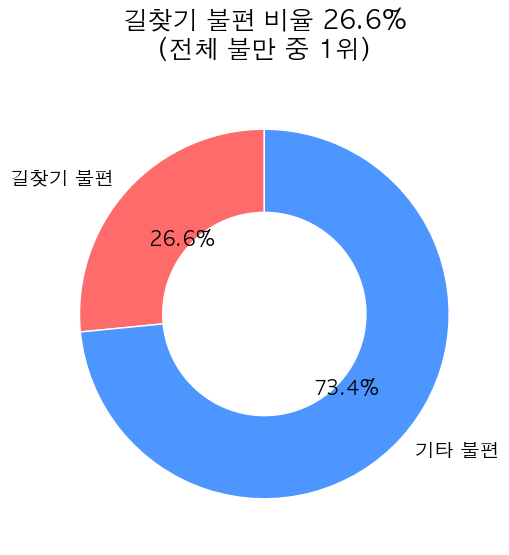

In [17]:
ratio = df["y_navi"].mean()

plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    [ratio, 1 - ratio],
    labels=['길찾기 불편', '기타 불편'],
    autopct='%.1f%%',
    startangle=90,
    colors=['#FF6B6B', '#4D96FF'],  # 더 부드러운 톤
    wedgeprops={'width': 0.45, 'edgecolor': 'white'}, 
    textprops={'fontsize': 14}
)

plt.title(
    f'길찾기 불편 비율 {ratio:.1%}\n(전체 불만 중 1위)',
    fontsize=18,
    pad=18
)

plt.savefig("길찾기_불편_비율_도넛차트.png", dpi=350, bbox_inches='tight')
plt.show()

### 탐색적 데이터 분석 인사이트 (EDA Insights)
- **불만 비율**: `y_navi` 비율이 전체의 20%를 넘고, 사용자들이 길찾기 기능에 상당한 불편을 느끼고 있음.
- **주요 키워드**: N-gram 분석 결과 'naver maps', 'google maps' 등 이동·지도 관련 키워드가 반복적으로 등장해 길찾기 맥락의 리뷰가 포함되어 있음을 확인

## 4. 토픽 모델링 (LDA Topic Modeling)
리뷰 데이터에서 잠재적인 토픽을 추출하여 어떤 주제들이 주로 논의되는지 파악

In [18]:
# LDA 준비
cv = CountVectorizer(max_df=0.9, min_df=5, stop_words='english')
X_bow = cv.fit_transform(df['text'])

print("Bag of Words Matrix Shape:", X_bow.shape)

Bag of Words Matrix Shape: (2030, 4969)


In [20]:
import matplotlib.pyplot as plt
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

zsh:1: command not found: pip


In [21]:
analyzer = cv.build_analyzer()
tokenized_texts = [analyzer(text) for text in df['text']]
dictionary = corpora.Dictionary(tokenized_texts)
corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

Coherence 계산을 위한 데이터 준비 중...
데이터 준비 완료.


In [22]:
min_topics = 2
max_topics = 15
step_size = 2
topics_range = range(min_topics, max_topics, step_size)

coherence_scores = []
perplexity_scores = []

print(f"탐색할 토픽 수: {list(topics_range)}")

탐색할 토픽 수: [2, 4, 6, 8, 10, 12, 14]


In [23]:
for k in topics_range:
    print(f"\n>>> 토픽 수 {k}개로 LDA 모델 학습 중...")
    
    lda_model = LatentDirichletAllocation(n_components=k, random_state=2026, n_jobs=-1)
    lda_model.fit(X_bow)
    
    # Perplexity 계산 (낮을수록 좋음)
    perplexity = lda_model.perplexity(X_bow)
    perplexity_scores.append(perplexity)
    
    # Coherence Score 계산 (높을수록 좋음)
    feature_names = cv.get_feature_names_out()
    top_words_per_topic = []
    for topic_idx, topic in enumerate(lda_model.components_):
        top_features_ind = topic.argsort()[:-15 - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        top_words_per_topic.append(top_features)
    
    # Gensim CoherenceModel 사용
    cm = CoherenceModel(topics=top_words_per_topic, texts=tokenized_texts, dictionary=dictionary, coherence='c_v')
    coherence = cm.get_coherence()
    coherence_scores.append(coherence)
    
    print(f"   - Perplexity: {perplexity:.2f}")
    print(f"   - Coherence Score: {coherence:.4f}")


>>> 토픽 수 2개로 LDA 모델 학습 중...
   - Perplexity: 2146.52
   - Coherence Score: 0.4024

>>> 토픽 수 4개로 LDA 모델 학습 중...
   - Perplexity: 2120.47
   - Coherence Score: 0.3969

>>> 토픽 수 6개로 LDA 모델 학습 중...
   - Perplexity: 2121.18
   - Coherence Score: 0.4105

>>> 토픽 수 8개로 LDA 모델 학습 중...
   - Perplexity: 2108.79
   - Coherence Score: 0.4918

>>> 토픽 수 10개로 LDA 모델 학습 중...
   - Perplexity: 2082.51
   - Coherence Score: 0.4563

>>> 토픽 수 12개로 LDA 모델 학습 중...
   - Perplexity: 2099.47
   - Coherence Score: 0.4227

>>> 토픽 수 14개로 LDA 모델 학습 중...
   - Perplexity: 2087.01
   - Coherence Score: 0.4536


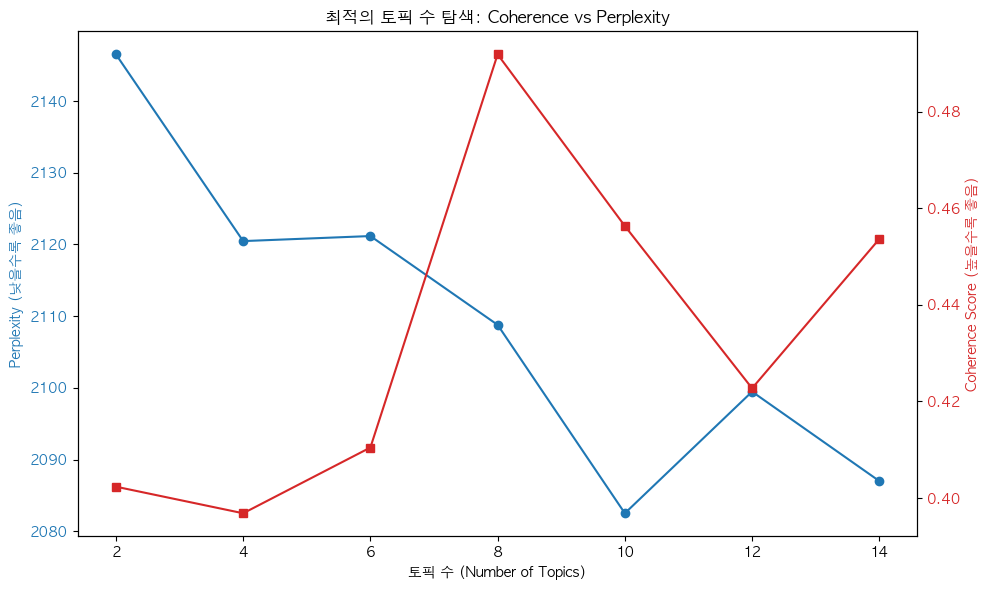

In [24]:
# 결과 시각화
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('토픽 수 (Number of Topics)')
ax1.set_ylabel('Perplexity (낮을수록 좋음)', color=color)
ax1.plot(topics_range, perplexity_scores, color=color, marker='o', label='Perplexity')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:red'
ax2.set_ylabel('Coherence Score (높을수록 좋음)', color=color)
ax2.plot(topics_range, coherence_scores, color=color, marker='s', label='Coherence')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('최적의 토픽 수 탐색: Coherence vs Perplexity')
fig.tight_layout()
plt.show()

### 최종 토픽 모델링 수행

앞선 시각화 결과를 바탕으로 결정한 **최적의 토픽 수(10)**를 적용하여 최종 모델을 학습

In [42]:
best_n_topics = 10 
lda = LatentDirichletAllocation(n_components=best_n_topics, random_state=2026, n_jobs=-1)
lda.fit(X_bow)

최종 모델 학습 시작 (토픽 수: 10)...
최종 LDA 모델 학습 완료.


Training LDA with 2 topics...
Topics: 2, Perplexity: 2146.52, Coherence: 0.4024
Training LDA with 4 topics...
Topics: 4, Perplexity: 2120.47, Coherence: 0.3969
Training LDA with 6 topics...
Topics: 6, Perplexity: 2121.18, Coherence: 0.4105
Training LDA with 8 topics...
Topics: 8, Perplexity: 2108.79, Coherence: 0.4918


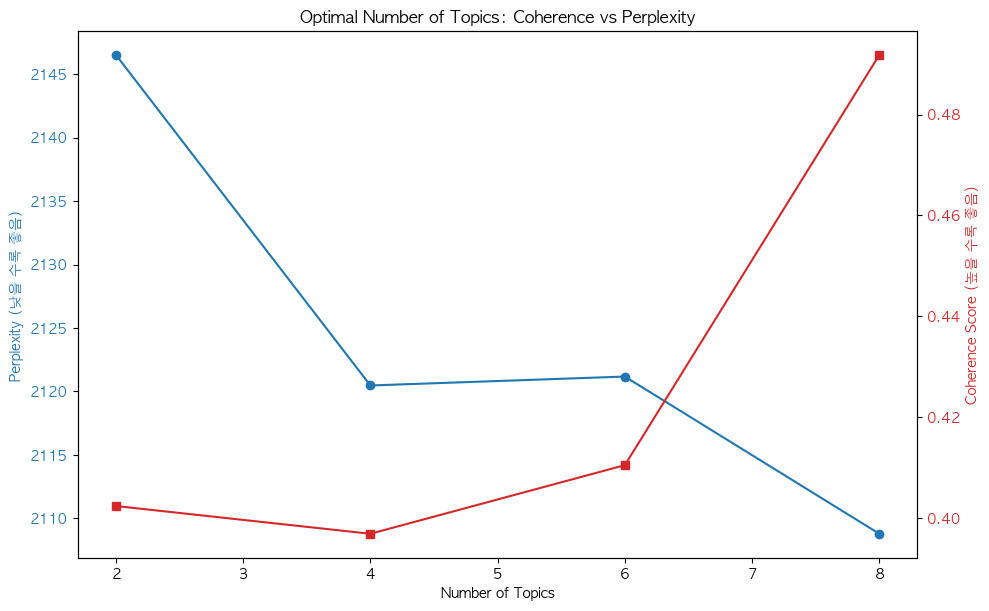

In [59]:
analyzer = cv.build_analyzer()
tokenized_texts = [analyzer(text) for text in df['text']]
dictionary = corpora.Dictionary(tokenized_texts)
corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

min_topics = 2
max_topics = 10
step_size = 2
topics_range = range(min_topics, max_topics, step_size)

coherence_scores = []
perplexity_scores = []

for k in topics_range:
    print(f"Training LDA with {k} topics...")
    lda_model = LatentDirichletAllocation(n_components=k, random_state=2026, n_jobs=-1)
    lda_model.fit(X_bow)
    
    perplexity = lda_model.perplexity(X_bow)
    perplexity_scores.append(perplexity)
    
    feature_names = cv.get_feature_names_out()
    top_words_per_topic = []
    for topic_idx, topic in enumerate(lda_model.components_):
        top_features_ind = topic.argsort()[:-15 - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        top_words_per_topic.append(top_features)
    
    cm = CoherenceModel(topics=top_words_per_topic, texts=tokenized_texts, dictionary=dictionary, coherence='c_v')
    coherence = cm.get_coherence()
    coherence_scores.append(coherence)
    print(f"Topics: {k}, Perplexity: {perplexity:.2f}, Coherence: {coherence:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Perplexity (낮을 수록 좋음)', color=color)
ax1.plot(topics_range, perplexity_scores, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:red'
ax2.set_ylabel('Coherence Score (높을 수록 좋음)', color=color)
ax2.plot(topics_range, coherence_scores, color=color, marker='s')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Optimal Number of Topics: Coherence vs Perplexity')
plt.show()

In [44]:
def print_topics(model, vectorizer, top_n=15):
    feature_names = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx}:")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-top_n - 1:-1]]))

print_topics(lda, cv)

Topic 0:
airport, ticket, tickets, flight, check, refund, air, passport, know, korean, incheon, like, buy, need, tax
Topic 1:
like, want, know, solo, feel, going, friends, really, things, life, love, think, years, home, family
Topic 2:
like, said, really, think, way, kind, felt, going, asked, surgery, right, took, know, able, told
Topic 3:
bus, like, city, really, night, tour, train, good, days, lot, hostel, took, bit, going, station
Topic 4:
card, korean, like, use, english, car, need, phone, know, used, money, cash, really, great, public
Topic 5:
days, visa, flight, japan, tokyo, 10, planning, week, places, plan, weeks, visit, asia, nights, flights
Topic 6:
guidelines, check, question, rules, welcome, post, general, details, notes, wiki, ourfaq, hover, bike, days, like
Topic 7:
skin, china, korean, clinic, hair, clinics, like, said, treatments, chinese, good, president, treatment, trade, looking
Topic 8:
hotel, like, winter, stay, really, hotels, cold, room, area, love, korean, airbn

In [45]:
# LDA 시각화 (pyLDAvis)
import pyLDAvis

pyLDAvis.enable_notebook()
lda_vis = pyLDAvis.lda_model.prepare(lda, X_bow, cv, mds='tsne')
pyLDAvis.save_html(lda_vis, 'LDA_토픽_시각화.html')
lda_vis

PreparedData(topic_coordinates=               x           y  topics  cluster       Freq
topic                                                   
1     -17.315512  -60.956310       1        1  20.739374
9     -13.802685    3.343005       2        1  13.871541
4      46.341404  -61.213573       3        1  13.430611
3      20.290159   49.505589       4        1  13.215744
2      19.719294  112.889450       5        1  11.801977
5      57.959518   -1.592164       6        1   7.844363
7      84.178383   59.606419       7        1   6.761561
0     -80.343582   33.327702       8        1   5.220767
6     -38.258148   77.323105       9        1   3.739654
8     -73.783897  -30.297239      10        1   3.374408, topic_info=            Term         Freq        Total Category  logprob  loglift
1200        days   957.000000   957.000000  Default  30.0000  30.0000
1772        food   757.000000   757.000000  Default  29.0000  29.0000
1983  guidelines   184.000000   184.000000  Default  28.0000  28.0000
841        check   358.000000   358.000000  Default  27.0000  27.0000
2480      korean  1032.000000  1032.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1924        good    33.101366   771.087655  Topic10  -5.2752   0.2407
5             10    26.983967   400.125863  Topic10  -5.4795   0.6924
2969        nice    25.957421   315.361788  Topic10  -5.5183   0.8917
1919       going    27.882787   848.237774  Topic10  -5.4468  -0.0262
1200        days    21.989694   957.009535  Topic10  -5.6842  -0.3843

[746 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
5         1  0.004998       10
5         2  0.097469       10
5         3  0.182443       10
5         4  0.172446       10
5         5  0.069978       10
...     ...       ...      ...
4955      7  0.203895     yoon
4955      9  0.029128     yoon
4958      1  0.900748  younger
4958      5  0.045037  younger
4958      9  0.030025  younger

[2457 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 10, 5, 4, 3, 6, 8, 1, 7, 9])

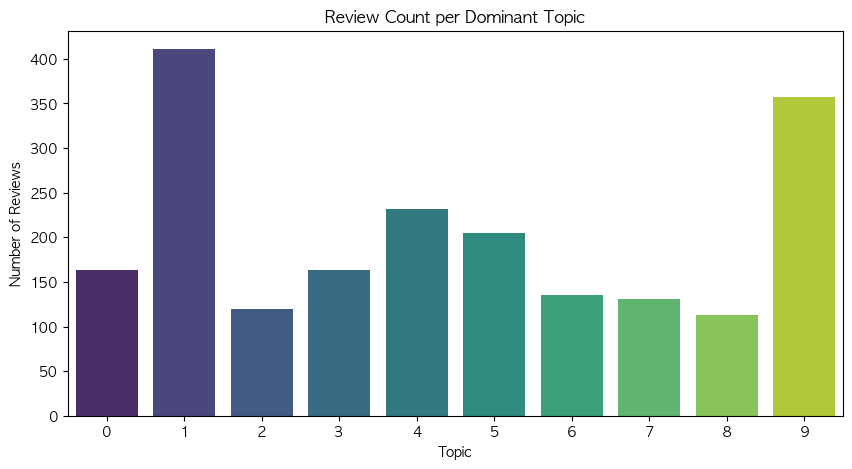

=== 토픽별 대표 리뷰 (Representative Reviews) ===

[Topic 0]
 - (Prob: 0.9986) global multinational branded products longer made philippines expensive electricity water caused oligarchs political corruption unfair land share 40 6...
 - (Prob: 0.9975) gwangan bridge olive young typically immediate tax refund need airport check receipt purchases either claim refund kiosks inside arrival area kiosks g...
 - (Prob: 0.9972) train workers strike explanation guy really like trains korail strike right led numerous cancellation trains things interesting look know strike short...

[Topic 1]
 - (Prob: 0.9986) 20 f want leave abusive father feels guilty scared five years living life feel like mine father biological dad man raised used whole world moments lau...
 - (Prob: 0.9986) 20 f wants leave abusive father scared feel guilty five years living life feel like mine father biological dad man raised used whole world moments lau...
 - (Prob: 0.9986) 20 f wants leave abusive father feels guilty scared five 

In [46]:
topic_values = lda.transform(X_bow)

df['Dominant_Topic'] = topic_values.argmax(axis=1)
df['Topic_Perc_Contrib'] = topic_values.max(axis=1)

topic_counts = df['Dominant_Topic'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis')
plt.title('Review Count per Dominant Topic')
plt.xlabel('Topic')
plt.ylabel('Number of Reviews')
plt.savefig("topic_review_count_bar.png", dpi=350, bbox_inches="tight")
plt.show()

def print_representative_reviews(df, n=3):
    print("=== 토픽별 대표 리뷰 (Representative Reviews) ===")
    for i in range(lda.n_components):
        print(f"\n[Topic {i}]")
        top_docs = df[df['Dominant_Topic'] == i].sort_values('Topic_Perc_Contrib', ascending=False).head(n)
        for idx, row in top_docs.iterrows():
            print(f" - (Prob: {row['Topic_Perc_Contrib']:.4f}) {str(row['text'])[:150]}...")

print_representative_reviews(df)

### 🔍 토픽 모델링 해석 (LDA Analysis)
- **Dominant Topic**: 위 그래프에서 가장 높게 솟은 막대는 사용자들이 가장 많이 언급하는 주제를 의미합니다.
- **Representative Reviews**: 모델이 분류한 각 토픽의 대표 리뷰를 읽어보면, 해당 토픽이 '앱 오류'인지 '지도 데이터 부정확'인지 구체적으로 해석할 수 있습니다. 토픽 간의 경계가 모호하다면 토픽 수(k) 조정이 필요할 수 있습니다.

## 5. 예측 모델링 (Predictive Modeling)
길찾기 불만(y_navi)이 없는 상태, 즉 '만족/재방문 의향 있음(y_revisit)'을 예측하는 모델을 LightGBM을 사용하여 구축

In [47]:
# y_navi가 1이면(불만), y_revisit은 0
# y_navi가 0이면(불만없음), y_revisit은 1
df['y_revisit'] = (df['y_navi'] == 0).astype(int)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['y_revisit'], test_size=0.3, stratify=df['y_revisit'], random_state=2026
)

print(f"Train Size: {X_train.shape}, Test Size: {X_test.shape}")

Train Size: (1421,), Test Size: (609,)


In [48]:
# LightGBM Pipeline 구축
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), min_df=5, max_df=0.8, max_features=10000)),
    ('clf', lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=7,
        num_leaves=64,
        min_child_samples=15,
        subsample=0.8,
        colsample_bytree=0.8,
        max_bin=255,
        random_state=2025,
        n_jobs=-1,
        verbose=-1
    ))
])

# 모델 학습
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.8, max_features=10000, min_df=5,
                                 ngram_range=(1, 3))),
                ('clf',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03,
                                max_bin=255, max_depth=7, min_child_samples=15,
                                n_estimators=1000, n_jobs=-1, num_leaves=64,
                                random_state=2025, subsample=0.8,
                                verbose=-1))])

## 6. 대안 예측 모델 비교 (Alternative Models Comparison)
기존의 LightGBM 모델과 다른 계열의 모델(Logistic Regression, Random Forest, SVM)을 비교하여 성능을 평가합니다.

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 동일한 TF-IDF 파라미터 사용
tfidf_params = {'ngram_range': (1, 3), 'min_df': 5, 'max_df': 0.8, 'max_features': 10000}

comparison_results = []

In [60]:
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', LogisticRegression(random_state=2025, max_iter=1000, C=1.0))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

comparison_results.append({'Model': 'Logistic Regression', 'Accuracy': acc_lr, 'F1-Score': f1_lr})
print(f"정확도(Accuracy): {acc_lr:.4f}, F1점수(F1-Score): {f1_lr:.4f}")
print(classification_report(y_test, y_pred_lr))

TypeError: TfidfVectorizer.__init__() takes 1 positional argument but 2 were given

In [51]:
pipe_rf = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=2025, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

comparison_results.append({'Model': 'Random Forest', 'Accuracy': acc_rf, 'F1-Score': f1_rf})
print(f"정확도(Accuracy): {acc_rf:.4f}, F1점수(F1-Score): {f1_rf:.4f}")
print(classification_report(y_test, y_pred_rf))

--- 랜덤 포레스트 (Random Forest) 학습 중 ---
정확도(Accuracy): 0.8539, F1점수(F1-Score): 0.9062
              precision    recall  f1-score   support

           0       0.84      0.56      0.67       162
           1       0.86      0.96      0.91       447

    accuracy                           0.85       609
   macro avg       0.85      0.76      0.79       609
weighted avg       0.85      0.85      0.84       609



In [52]:
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(**tfidf_params)),
    ('clf', LinearSVC(random_state=2025, dual=False))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

comparison_results.append({'Model': 'Linear SVM', 'Accuracy': acc_svm, 'F1-Score': f1_svm})
print(f"정확도(Accuracy): {acc_svm:.4f}, F1점수(F1-Score): {f1_svm:.4f}")
print(classification_report(y_test, y_pred_svm))

--- 선형 SVM (Linear SVM) 학습 중 ---
정확도(Accuracy): 0.8555, F1점수(F1-Score): 0.9066
              precision    recall  f1-score   support

           0       0.82      0.58      0.68       162
           1       0.86      0.96      0.91       447

    accuracy                           0.86       609
   macro avg       0.84      0.77      0.79       609
weighted avg       0.85      0.86      0.85       609



In [53]:
y_pred_lgbm = pipeline.predict(X_test)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)

comparison_results.append({'Model': 'LightGBM', 'Accuracy': acc_lgbm, 'F1-Score': f1_lgbm})
print(f"LightGBM (Baseline) - 정확도: {acc_lgbm:.4f}, F1점수: {f1_lgbm:.4f}")

LightGBM (Baseline) - 정확도: 0.9327, F1점수: 0.9556


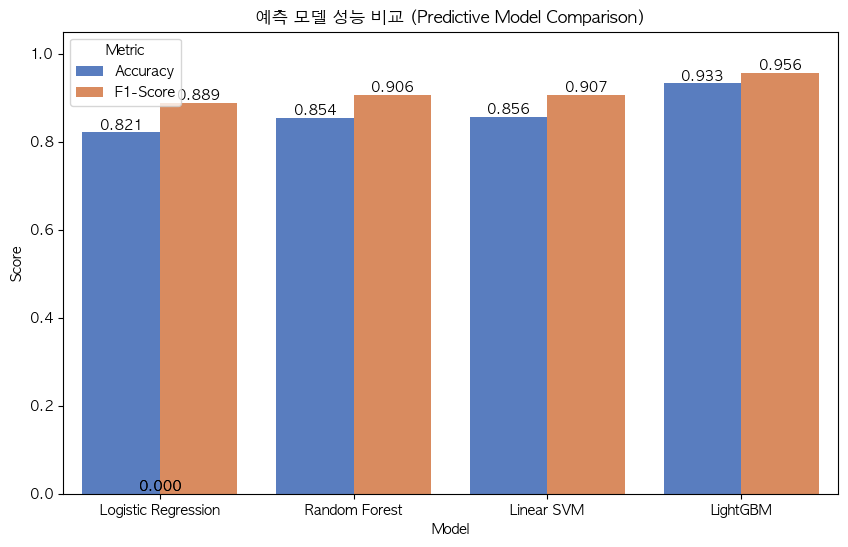

In [54]:
results_df = pd.DataFrame(comparison_results)

plt.figure(figsize=(10, 6))
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='muted')
plt.title('예측 모델 성능 비교 (Predictive Model Comparison)')
plt.ylim(0, 1.05)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), 
                 textcoords='offset points')
plt.show()

In [55]:
# 모델 평가
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC AUC Score: 0.9365

Confusion Matrix:
[[127  35]
 [  6 441]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       162
           1       0.93      0.99      0.96       447

    accuracy                           0.93       609
   macro avg       0.94      0.89      0.91       609
weighted avg       0.93      0.93      0.93       609



In [56]:
error_df = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'predicted': y_pred
})

# 예측: 만족, 실제: 불만 -> 불만을 놓친 케이스
fp_cases = error_df[(error_df['actual'] == 0) & (error_df['predicted'] == 1)]

# 예측: 불만, 실제: 만족
fn_cases = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)]

print(f"불만인데 만족으로 오분류: {len(fp_cases)} 건 (놓친 불만)")
print(f"만족인데 불만으로 오분류: {len(fn_cases)} 건 (허위 경보)")

def print_error_samples(cases, title, n=5):
    print(f"\n--- {title} Top {n} Samples ---")
    if len(cases) == 0:
        print("No samples found.")
        return
    for i, row in cases.head(n).iterrows():
        print(f"[Actual: {row['actual']} | Pred: {row['predicted']}] {str(row['text'])[:150]}...")
        print("-" * 30)

print_error_samples(fp_cases, "False Positive (Missed Complaints)")
print_error_samples(fn_cases, "False Negative (False Alarms)")

False Positives (불만인데 만족으로 오분류): 35 건 (놓친 불만)
False Negatives (만족인데 불만으로 오분류): 6 건 (허위 경보)

--- False Positive (Missed Complaints) Top 5 Samples ---
[Actual: 0 | Pred: 1] 15 days taiwan split still catch autumn foliage sure color still turning little autumn foliage 4 days ago left returning next week give another update...
------------------------------
[Actual: 0 | Pred: 1] first visiting hi im visiting april 25 early may date comes nearer im getting anxious going solo plans want sightsee hike shop eat really immerse loca...
------------------------------
[Actual: 0 | Pred: 1] balkans issue transportation hi everyone currently planning balkans bit worried regarding transportation routes particularly worried wondering could h...
------------------------------
[Actual: 0 | Pred: 1] stop taking advice failure passport bros like wes asian bro following guys doomed failure edit 2 deleted video wes refused help asian dudes dating col...
------------------------------
[Actual: 0 | Pred: 1] a

### 모델 성능 및 에러 분석 (Model Performance & Error Analysis)
- **AUC Score**: 0.8 이상이면 우수한 분류 모델
- **오분류(Error) 패턴**: 
  - **False Negative (과도한 불만 예측)**: 사용자 의도는 긍정적이나 '단어' 때문에 불만으로 오해한 경우.
  - **False Positive (놓친 불만)**: 실제로는 불만인데 모델이 긍정으로 예측한 경우. 비꼬는 표현(Sarcasm)이나 짧고 모호한 리뷰에서 주로 발생할 수 있음. 이 케이스를 줄이는 것이 서비스 품질 개선에 중요

## 6. 모델 해석 (Model Interpretation with SHAP)
어떤 단어나 표현이 모델의 예측(만족 vs 불만)에 가장 큰 영향을 미쳤는지 SHAP Value를 통해 분석합니다.

### 모델 해석 및 설명 가능성 (XAI with SHAP)

모델의 정확도(Accuracy)만으로는 비즈니스 인사이트를 얻기 어려움
**SHAP (SHapley Additive exPlanations)** 값을 사용하여 모델이 왜 특정 예측을 했는지 분석

*   **기여도 분석:** 어떤 단어(특성)가 재방문 의도를 높이거나 낮추는데 기여했는지 시각화

In [57]:
vectorizer = pipeline.named_steps["tfidf"]
model = pipeline.named_steps["clf"]
X_test_vec = vectorizer.transform(X_test)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_vec)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

limit = 2000
if X_test_vec.shape[0] > limit:
    X_vis = X_test_vec[:limit].toarray()
    shap_vis = shap_values[:limit]
else:
    X_vis = X_test_vec.toarray()
    shap_vis = shap_values

if hasattr(shap_vis, 'toarray'):
    shap_vis = shap_vis.toarray()

print(f"Original Shape: {shap_values.shape}")
print(f"Visualization Shape: {shap_vis.shape}")

Original Shape: (609, 5519)
Visualization Shape: (609, 5519)


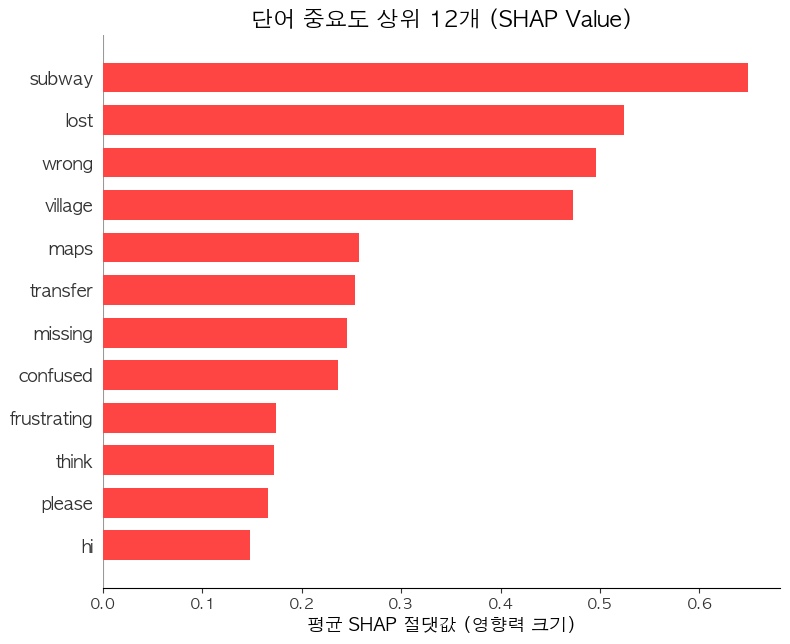

In [58]:
plt.figure(figsize=(10, 6))
feature_names = vectorizer.get_feature_names_out().tolist()

shap.summary_plot(
    shap_vis,
    X_vis,
    feature_names=feature_names,
    max_display=12,
    plot_type="bar",
    show=False,
    color='#ff4444'
)

plt.title('단어 중요도 상위 12개 (SHAP Value)', fontsize=16)
plt.xlabel("평균 SHAP 절댓값 (영향력 크기)")
plt.show()